In [2]:
import numpy as np
import matplotlib.pyplot as plt
import numpy.linalg as la
import pickle
import linalg_helpers as lh
from create_plots_with_zero_pred import tf_preds
from core import Config
from models import GPT2, CnnKF
from data_train import set_config_params
import torch


/home/sultand/.conda/envs/myenv310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Could not import netCDF4's package ==> I/O will not be available in this format
/home/sultand/interleaved_time_series/TFs_do_KF_ICL/src
Using device: cpu
/home/sultand/interleaved_time_series/TFs_do_KF_ICL/src
Using device: cpu
CUDA_VISIBLE_DEVICES: -1


In [3]:
#import the test data
with open('/data/shared/ICL_Kalman_Experiments/train_and_test_data/ortho_haar/val_interleaved_traces_ortho_haar_ident_C_haystack_len_1_state_dim_5.pkl', 'rb') as f:
    data_dict = pickle.load(f)
    data = data_dict['multi_sys_ys'][0,0,:,2:12, -5:].transpose(0,2,1)
    multi_sys_ys = data_dict['multi_sys_ys']

print(data_dict.keys())
print(data.shape)
lh.print_matrix(data[0], "data[0]")

dict_keys(['multi_sys_ys', 'sys_choices_per_config', 'sys_dict_per_config', 'tok_seg_lens_per_config', 'seg_starts_per_config', 'real_seg_lens_per_config', 'sys_inds_per_config'])
(1000, 5, 10)
Matrix data[0]:
    0.0941     0.0417    -0.0063     0.1246    -0.2424     0.2163    -0.3604     0.2046    -0.2338     0.1022 
   -0.1592     0.2969    -0.1355     0.1852     0.1027    -0.1714     0.2856    -0.3823     0.1961    -0.2236 
   -0.2212     0.3651    -0.5498     0.5809    -0.4315     0.3158     0.0082    -0.1281     0.2787    -0.2556 
   -0.8567     0.6332    -0.2456    -0.2442     0.5901    -0.8021     0.7135    -0.4151    -0.0118     0.4860 
    0.0526    -0.4424     0.6624    -0.6106     0.4648    -0.0218    -0.3149     0.6656    -0.8055     0.6767 


In [4]:
def vanilla_pinv_pred(data):
    pseudo_preds = np.zeros_like(data)
    for i in range(data.shape[2]):
        if i > 1:
            # print(f"i={i}")
            # lh.print_matrix(data[0,:,1:(i)], f"data[0,:,1:{i}]")
            # lh.print_matrix(data[0,:,0:(i-1)], f"data[0,:,0:{i-1}]")
            # print(f"data[0,:,{i-1}]: {data[0,:,i-1]}")
            # print(f"shape of einsum output: {np.einsum('bij,bj->bi', la.pinv(data[:,:,0:(i-1)]), data[:,:,i-1]).shape}")
            mat = np.einsum('bij,bjk->bik', data[:,:,1:i], la.pinv(data[:,:,0:(i-1)]))
            lh.print_matrix(mat[0], f"mat[0] at i={i}")
            pseudo_preds[:,:,i] = np.einsum('bij,bj->bi', data[:,:,1:i], np.einsum('bij,bj->bi', la.pinv(data[:,:,0:(i-1)]), data[:,:,i-1]))
            # print(f"pseudo_preds[:,:,{i}].shape: {pseudo_preds[:,:,i].shape}")

    return pseudo_preds

def noisy_pinv_pred(data, scale=1e-15):
    pseudo_preds = np.zeros_like(data)
    first_mat = scale*np.random.randn(data.shape[0], data.shape[1], data.shape[1])/np.sqrt(data.shape[1])
    # first_mat = np.zeros((data.shape[0], data.shape[1], data.shape[1]))
    lh.print_matrix(first_mat[0], "first_mat[0] initial")
    second_mat = scale*np.random.randn(data.shape[0], data.shape[1], data.shape[1])/np.sqrt(data.shape[1])
    # second_mat = np.zeros((data.shape[0], data.shape[1], data.shape[1]))
    for i in range(data.shape[2]):
        if i < 7 and i > 1:
            first_mat[:,:,0:(i-1)] = data[:,:,1:i]
            lh.print_matrix(first_mat[0], f"first_mat[0] at i={i}")
            second_mat[:,:,0:i-1] = data[:,:,0:i-1]
            lh.print_matrix(second_mat[0], f"second_mat[0] at i={i}")
            
            mat = np.einsum('bij,bjk->bik', first_mat, la.pinv(second_mat))
            lh.print_matrix(mat[0], f"mat[0] at i={i}")
            pseudo_preds[:,:,i] = np.einsum('bij,bj->bi', first_mat, np.einsum('bij,bj->bi', la.pinv(second_mat), data[:,:,i-1]))
            # print(f"pseudo_preds[:,:,{i}].shape: {pseudo_preds[:,:,i].shape}")
        elif i > 1:
            # print(f"i={i}")
            # lh.print_matrix(data[0,:,1:(i)], f"data[0,:,1:{i}]")
            # lh.print_matrix(data[0,:,0:(i-1)], f"data[0,:,0:{i-1}]")
            # print(f"data[0,:,{i-1}]: {data[0,:,i-1]}")
            # print(f"shape of einsum output: {np.einsum('bij,bj->bi', la.pinv(data[:,:,0:(i-1)]), data[:,:,i-1]).shape}")
            pseudo_preds[:,:,i] = np.einsum('bij,bj->bi', data[:,:,1:i], np.einsum('bij,bj->bi', la.pinv(data[:,:,0:(i-1)]), data[:,:,i-1]))
            # print(f"pseudo_preds[:,:,{i}].shape: {pseudo_preds[:,:,i].shape}")

    return pseudo_preds

def proj_pseudo_preds(proj, data):
    pseudo_preds = np.zeros_like(data)
    proj_data = np.einsum('ij,bjk->bik', proj, data)
    lh.print_matrix(proj, "proj")
    lh.print_matrix(la.pinv(proj), "la.pinv(proj)")
    lh.print_matrix(la.inv(proj), "la.inv(proj)")
    print(f"proj_data.shape: {proj_data.shape}")
    for i in range(data.shape[2]):
        if i > 1:
            mat = np.einsum('ij,bjk->bik',la.pinv(proj), np.einsum('bij,bjk->bik', proj_data[:,:,1:i], np.einsum('bij,jk->bik',la.pinv(proj_data[:,:,0:(i-1)]), proj)))
            lh.print_matrix(mat[0], f"mat[0] at i={i}")
            pseudo_preds[:,:,i] = np.einsum('ij,bj->bi',la.pinv(proj),np.einsum('bij,bj->bi', proj_data[:,:,1:i], np.einsum('bij,bj->bi', la.pinv(proj_data[:,:,0:(i-1)]), proj_data[:,:,i-1])))

    return pseudo_preds

noisy_pseudo_preds = noisy_pinv_pred(data)
lh.print_matrix(noisy_pseudo_preds[0], "noisy_pseudo_preds[0]")

Matrix first_mat[0] initial:
    0.0000     0.0000    -0.0000     0.0000    -0.0000 
    0.0000     0.0000     0.0000     0.0000    -0.0000 
   -0.0000     0.0000     0.0000    -0.0000     0.0000 
   -0.0000    -0.0000    -0.0000     0.0000    -0.0000 
   -0.0000    -0.0000     0.0000     0.0000    -0.0000 
Matrix first_mat[0] at i=2:
    0.0417     0.0000    -0.0000     0.0000    -0.0000 
    0.2969     0.0000     0.0000     0.0000    -0.0000 
    0.3651     0.0000     0.0000    -0.0000     0.0000 
    0.6332    -0.0000    -0.0000     0.0000    -0.0000 
   -0.4424    -0.0000     0.0000     0.0000    -0.0000 
Matrix second_mat[0] at i=2:
    0.0941    -0.0000    -0.0000    -0.0000    -0.0000 
   -0.1592    -0.0000     0.0000     0.0000     0.0000 
   -0.2212    -0.0000    -0.0000    -0.0000     0.0000 
   -0.8567    -0.0000    -0.0000     0.0000    -0.0000 
    0.0526    -0.0000     0.0000    -0.0000    -0.0000 
Matrix mat[0] at i=2:
    0.0048    -0.0081    -0.0113    -0.0436     0.00

In [5]:
random_proj = np.random.randn(5,5)

In [10]:
print(la.svd(random_proj))

SVDResult(U=array([[ 0.05442576,  0.61899278, -0.02818709,  0.28023452,  0.73113601],
       [-0.46728556, -0.56910391, -0.26603385,  0.54672334,  0.29679035],
       [-0.53715468,  0.19106275,  0.77510311,  0.21065185, -0.17262921],
       [ 0.23674159,  0.30110769, -0.22488588,  0.7058783 , -0.55176966],
       [ 0.65886289, -0.40718283,  0.52637723,  0.28270803,  0.20761748]]), S=array([3.15994429, 2.37674133, 2.08036227, 0.60091287, 0.1833722 ]), Vh=array([[-0.28752403, -0.37887226,  0.2363205 ,  0.63584427,  0.56003609],
       [ 0.04121549, -0.02693229, -0.95920668,  0.24840703,  0.12566789],
       [-0.20467585,  0.08390527,  0.04707897,  0.60932185, -0.75998563],
       [ 0.09192467,  0.90214699,  0.0904269 ,  0.27820011,  0.30349355],
       [ 0.93020904, -0.18660433,  0.11696882,  0.29210886, -0.02967599]]))


In [6]:
random_proj_pseudo_preds = proj_pseudo_preds(random_proj, data)
print(f"random_proj_pseudo_preds.shape: {random_proj_pseudo_preds.shape}")
lh.print_matrix(random_proj_pseudo_preds[0], "random_proj_pseudo_preds[0]")

Matrix proj:
    0.1634     0.0172    -1.3424     0.5251     0.3729 
    0.5629     0.8357     0.9585    -1.5048    -0.4782 
    0.1589     0.8863    -0.7530     0.0420    -2.0796 
   -0.1450     0.0596    -0.5052     0.4568     0.9962 
   -0.8116    -0.5247     1.4917     1.8090     0.2626 
Matrix la.pinv(proj):
    3.7603     1.6480    -0.8676    -2.6852     0.9776 
   -0.3380     0.5705     0.5854     1.5804     0.1600 
    0.2622     0.4603    -0.1782    -0.3546     0.4005 
    1.3618     0.4945    -0.0386    -0.5389     0.7058 
    0.0759     0.2124    -0.2339     0.5858     0.0121 
Matrix la.inv(proj):
    3.7603     1.6480    -0.8676    -2.6852     0.9776 
   -0.3380     0.5705     0.5854     1.5804     0.1600 
    0.2622     0.4603    -0.1782    -0.3546     0.4005 
    1.3618     0.4945    -0.0386    -0.5389     0.7058 
    0.0759     0.2124    -0.2339     0.5858     0.0121 
proj_data.shape: (1000, 5, 10)
Matrix mat[0] at i=2:
    0.0191     0.0156    -0.0137    -0.0466    -0.0

In [7]:
pseudo_preds = vanilla_pinv_pred(data)
print("Pseudo Predictions shape:", pseudo_preds.shape)
lh.print_matrix(pseudo_preds[0], "pseudo_preds[0]")

Matrix mat[0] at i=2:
    0.0048    -0.0081    -0.0113    -0.0436     0.0027 
    0.0341    -0.0577    -0.0801    -0.3102     0.0190 
    0.0419    -0.0709    -0.0985    -0.3816     0.0234 
    0.0727    -0.1230    -0.1708    -0.6617     0.0406 
   -0.0508     0.0859     0.1193     0.4623    -0.0284 
Matrix mat[0] at i=3:
    0.0193     0.0115     0.0103    -0.0542    -0.0452 
    0.0918     0.0201     0.0054    -0.3521    -0.1710 
   -0.0806    -0.2360    -0.2799    -0.2928     0.4267 
    0.2177     0.0724     0.0439    -0.7668    -0.4369 
    0.0958     0.2834     0.3364     0.3560    -0.5110 
Matrix mat[0] at i=4:
    0.2528     0.3407    -0.2946    -0.0074     0.0130 
    0.4348     0.5037    -0.4424    -0.2834    -0.0855 
   -0.0178    -0.1475    -0.3618    -0.2802     0.4424 
    0.0484    -0.1663     0.2649    -0.8007    -0.4792 
    0.1575     0.3704     0.2558     0.3684    -0.4956 


Matrix mat[0] at i=5:
    0.1070    -0.0187    -0.8611     0.1600    -0.4699 
    0.5177     0.7080    -0.1204    -0.3786     0.1891 
   -0.0088    -0.1252    -0.3266    -0.2906     0.4724 
    0.0237    -0.2273     0.1687    -0.7722    -0.5612 
    0.1714     0.4047     0.3098     0.3524    -0.4496 
Matrix mat[0] at i=6:
    0.1226    -0.0284    -0.8589     0.1630    -0.4689 
    0.6778     0.6084    -0.0985    -0.3475     0.1999 
   -0.6361     0.2651    -0.4125    -0.4125     0.4298 
   -0.0507    -0.1811     0.1585    -0.7867    -0.5662 
   -0.3439     0.7252     0.2393     0.2523    -0.4846 
Matrix mat[0] at i=7:
    0.1226    -0.0284    -0.8589     0.1630    -0.4689 
    0.6778     0.6084    -0.0985    -0.3475     0.1999 
   -0.6361     0.2651    -0.4125    -0.4125     0.4298 
   -0.0507    -0.1811     0.1585    -0.7867    -0.5662 
   -0.3439     0.7252     0.2393     0.2523    -0.4846 
Matrix mat[0] at i=8:
    0.1226    -0.0284    -0.8589     0.1630    -0.4689 
    0.6778     0

In [8]:
lh.print_matrix((pseudo_preds - data)[0], "pseudo_preds[0] - data[0]")
lh.print_matrix((noisy_pseudo_preds - data)[0], "noisy_pseudo_preds[0] - data[0]")

print(f"pseudo_preds[0,:, 6]: {pseudo_preds[0,:,6]}")
print(f"noisy_pseudo_preds[0,:, 6]: {noisy_pseudo_preds[0,:,6]}")

Matrix pseudo_preds[0] - data[0]:
   -0.0941    -0.0417    -0.0288    -0.1486     0.1598     0.0034     0.0000     0.0000     0.0000    -0.0000 
    0.1592    -0.2969    -0.1143    -0.2183    -0.0908     0.0351     0.0000     0.0000     0.0000     0.0000 
    0.2212    -0.3651     0.2425    -0.0399    -0.0099    -0.1375     0.0000     0.0000     0.0000     0.0000 
    0.8567    -0.6332    -0.2871     0.1078     0.0271    -0.0163     0.0000     0.0000     0.0000     0.0000 
   -0.0526     0.4424    -0.2902    -0.0393    -0.0152    -0.1129    -0.0000     0.0000    -0.0000    -0.0000 
Matrix noisy_pseudo_preds[0] - data[0]:
   -0.0941    -0.0417    -0.0288    -0.1486     0.1598     0.0034     0.0000     0.0000     0.0000    -0.0000 
    0.1592    -0.2969    -0.1143    -0.2183    -0.0908     0.0351    -0.0000     0.0000     0.0000     0.0000 
    0.2212    -0.3651     0.2425    -0.0399    -0.0099    -0.1375    -0.0000     0.0000     0.0000     0.0000 
    0.8567    -0.6332    -0.2871     0

Pseudo Prediction Norms shape: (1000, 10)
Noisy Pseudo Prediction Norms shape: (1000, 10)
Random Projection Pseudo Prediction Norms shape: (1000, 10)
Mean Errors: [1.0187368e+00 1.0187368e+00 7.8013700e-01 5.7857752e-01 4.5491108e-01
 8.4410496e-02 3.4288768e-12 1.8799313e-12 2.8171297e-13 2.1115680e-13]
Mean Noisy Errors: [1.0187368e+00 1.0187368e+00 8.9951086e-01 7.9884648e-01 5.0484365e-01
 8.5759215e-02 8.5638428e-15 1.8799313e-12 2.8171297e-13 2.1115680e-13]
Mean Random Projection Errors: [1.0187368e+00 1.0187368e+00 9.8404461e-01 9.6011138e-01 1.2838222e+00
 4.2877749e-01 8.5638428e-15 8.2504126e-15 4.1805917e-15 3.7039955e-15]


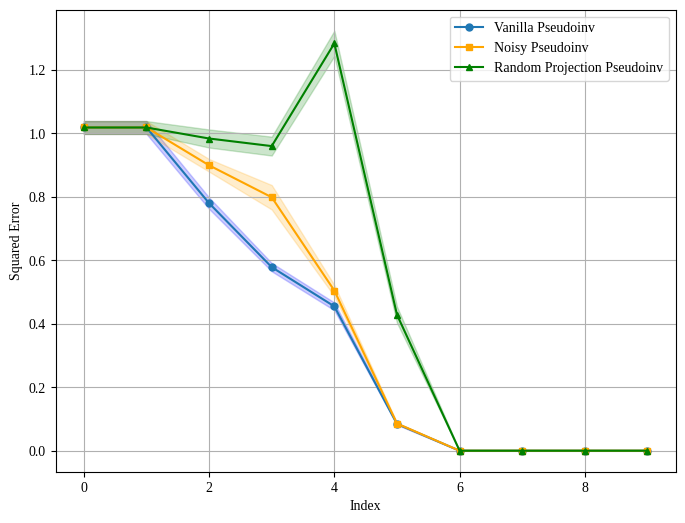

In [9]:
#compute errors of pseudoinv predictions
pseudo_pred_errs = la.norm(pseudo_preds - data, axis=1)**2
print("Pseudo Prediction Norms shape:", pseudo_pred_errs.shape)
noisy_pseudo_pred_errs = la.norm(noisy_pseudo_preds - data, axis=1)**2
print("Noisy Pseudo Prediction Norms shape:", noisy_pseudo_pred_errs.shape)
random_proj_pseudo_pred_errs = la.norm(random_proj_pseudo_preds - data, axis=1)**2
print("Random Projection Pseudo Prediction Norms shape:", random_proj_pseudo_pred_errs.shape)

mean_errs = np.mean(pseudo_pred_errs, axis=0)
print("Mean Errors:", mean_errs)
std_errs = np.std(pseudo_pred_errs, axis=0)/np.sqrt(pseudo_pred_errs.shape[0])
mean_noisy_errs = np.mean(noisy_pseudo_pred_errs, axis=0)
print("Mean Noisy Errors:", mean_noisy_errs)
std_noisy_errs = np.std(noisy_pseudo_pred_errs, axis=0)/np.sqrt(noisy_pseudo_pred_errs.shape[0])
mean_random_proj_errs = np.mean(random_proj_pseudo_pred_errs, axis=0)
print("Mean Random Projection Errors:", mean_random_proj_errs)
std_random_proj_errs = np.std(random_proj_pseudo_pred_errs, axis=0)/np.sqrt(random_proj_pseudo_pred_errs.shape[0])



plt.figure(figsize=(8,6))
plt.plot(mean_errs, label='Vanilla Pseudoinv', marker='o', markersize=5)
plt.fill_between(np.arange(len(mean_errs)), mean_errs - std_errs, mean_errs + std_errs, color='b', alpha=0.2)
plt.plot(mean_noisy_errs, label='Noisy Pseudoinv', marker='s', markersize=5, color='orange')
plt.fill_between(np.arange(len(mean_noisy_errs)), mean_noisy_errs - std_noisy_errs, mean_noisy_errs + std_noisy_errs, color='orange', alpha=0.2)
plt.plot(mean_random_proj_errs, label='Random Projection Pseudoinv', marker='^', markersize=5, color='green')
plt.fill_between(np.arange(len(mean_random_proj_errs)), mean_random_proj_errs - std_random_proj_errs, mean_random_proj_errs + std_random_proj_errs, color='green', alpha=0.2)
plt.xlabel('Index')
plt.ylabel('Squared Error')
# plt.yscale('log')
# plt.ylim(0, 10)
plt.legend()
plt.grid(True)

In [5]:
#norm of pseudo predictions
pseudo_pred_norms = la.norm(pseudo_preds, axis=1)**2
print("Pseudo Prediction Norms shape:", pseudo_pred_norms.shape)


Pseudo Prediction Norms shape: (1000, 10)


In [6]:
config = Config()
model_name = "ortho_haar_big_mask_backstory_no_leak" #"ortho_haar_medium_single_gpu"

output_dir, ckpt_dir, experiment_name = set_config_params(config, model_name)

datasource = "val"


colors = ['#000000', '#005CAB', '#E31B23', '#FFC325', '#00A651', '#9B59B6']



ORTHO HAAR BIG MASK BACKSTORY NO LEAK




In [13]:
device = "cuda" if torch.cuda.is_available() else "cpu"  # check if cuda is available

ckpt = 150000
filename = f"step={ckpt}.ckpt"
ckpt_path = ckpt_dir + "/checkpoints/" + filename

config.override("ckpt_path", ckpt_path)
#load model from ckpt_dir``
model = GPT2.load_from_checkpoint(config.ckpt_path,
                                n_dims_in=config.n_dims_in, n_positions=config.n_positions,
                                n_dims_out=config.n_dims_out, n_embd=config.n_embd,
                                n_layer=config.n_layer, n_head=config.n_head, use_pos_emb=config.use_pos_emb, map_location=device, strict=True).eval().to(device)

print(model)
# print(f"number of training examples: {ckpt*config.devices*config.batch_size}")

GPT2(
  (_read_in): Linear(in_features=57, out_features=192, bias=True)
  (_backbone): GPT2Model(
    (wte): Embedding(50257, 192)
    (wpe): Embedding(2048, 192)
    (drop): Dropout(p=0.0, inplace=False)
    (h): ModuleList(
      (0-23): 24 x GPT2Block(
        (ln_1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=576, nx=192)
          (c_proj): Conv1D(nf=192, nx=192)
          (attn_dropout): Dropout(p=0.0, inplace=False)
          (resid_dropout): Dropout(p=0.0, inplace=False)
        )
        (ln_2): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=768, nx=192)
          (c_proj): Conv1D(nf=192, nx=768)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.0, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
  )
  (_read_out): Linear(in_features=192, out_features=5, bias=True)
)


In [14]:
model_preds = tf_preds(multi_sys_ys, model, device, config)
print("Model Predictions shape:", model_preds.shape)

flattened_I.dtype: float32
before validation_loader
time elapsed for creating validation_loader: 0.00013899803161621094 sec
before predict_steps
time elapsed for predict_steps: 3.538215192159017 min
Model Predictions shape: (50, 1, 1000, 25, 5)


In [15]:
first_seg_preds = model_preds[0,0,:,2:12, -5:].transpose(0,2,1)
print("First Segment Predictions shape:", first_seg_preds.shape)
lh.print_matrix(first_seg_preds[0], "first_seg_preds[0]")

model_pred_norms = la.norm(first_seg_preds, axis=1)**2
print("Model Prediction Norms shape:", model_pred_norms.shape)

First Segment Predictions shape: (1000, 5, 10)
Matrix first_seg_preds[0]:
   -0.0660     0.0473     0.0774     0.1295    -0.0503     0.2492    -0.3367     0.2163    -0.2741     0.0540 
   -0.1862    -0.0491    -0.1150     0.1027     0.0345    -0.1172     0.3783    -0.3285     0.2639    -0.2254 
    0.0020    -0.0855    -0.1223     0.4207    -0.5301     0.1504     0.0718    -0.1387     0.3154    -0.2323 
   -0.2032    -0.3439    -0.4482     0.1336     0.5893    -0.8263     0.6983    -0.4159    -0.0365     0.4874 
    0.0606    -0.0317     0.0239    -0.5504     0.3800    -0.1049    -0.2814     0.6873    -0.7528     0.6884 
Model Prediction Norms shape: (1000, 10)


Mean Norms: [0.         0.         0.23860005 0.44015968 0.5638259  0.93432605
 1.018737   1.0187368  1.0187368  1.0187367 ]
Model Mean Norms: [0.08398451 0.1974881  0.23762102 0.5959067  0.6981635  0.9316904
 0.9980817  1.0162075  1.0180457  1.0215644 ]


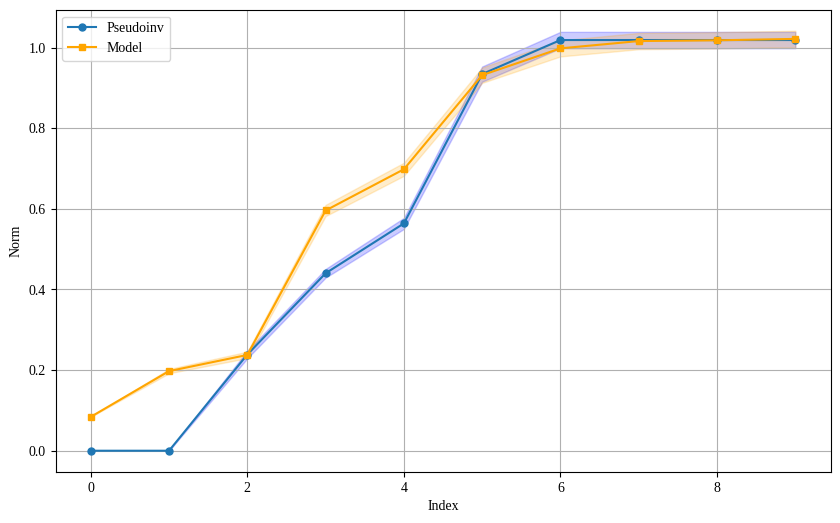

In [16]:
#plot the mean and std of the norms over time
mean_norms = np.mean(pseudo_pred_norms, axis=0)
print("Mean Norms:", mean_norms)
std_norms = np.std(pseudo_pred_norms, axis=0)/np.sqrt(pseudo_pred_norms.shape[0])

model_mean_norms = np.mean(model_pred_norms, axis=0)
print("Model Mean Norms:", model_mean_norms)
model_std_norms = np.std(model_pred_norms, axis=0)/np.sqrt(model_pred_norms.shape[0])


plt.figure(figsize=(10,6))
plt.plot(mean_norms, label='Pseudoinv', marker='o', markersize=5)
plt.fill_between(np.arange(len(mean_norms)), mean_norms - std_norms, mean_norms + std_norms, color='b', alpha=0.2)

plt.plot(model_mean_norms, label=f'Model', marker='s', markersize=5, color='orange')
plt.fill_between(np.arange(len(model_mean_norms)), model_mean_norms - model_std_norms, model_mean_norms + model_std_norms, color='orange', alpha=0.2)
plt.xlabel('Index')
plt.ylabel('Norm')
plt.legend()
#add grid
plt.grid(True)

